# Evaluación en Holdout — Métricas Finales

**Objetivo:** Evaluación honesta del modelo sobre el test split que no se tocó durante el entrenamiento.

**Métricas reportadas:**
- Accuracy, Precision, Recall, F1 (clase falsificado como positivo)
- AUC-ROC con curva completa
- AUC-PR (Precision-Recall)
- Confusion matrix con valores absolutos y porcentajes
- Análisis de threshold óptimo
- Distribución de scores por clase
- Top errores (falsos positivos y negativos más confiados)
- Tiempo de inferencia p50/p90/p95 en CPU

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns
import torch
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay

sys.path.insert(0, str(Path.cwd().parent))

from src.data.loader import create_dataloaders
from src.models.classifier import DocumentClassifier
from src.models.evaluator import ModelEvaluator

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 11

DEVICE   = "mps" if torch.backends.mps.is_available() else "cpu"
CKPT     = Path.cwd().parent / "models" / "saved" / "efficientnet_b0_best.pt"
DATA_DIR = Path.cwd().parent / "data" / "samples"
FIG_DIR  = Path.cwd().parent / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device     : {DEVICE}")
print(f"Checkpoint : {CKPT.name}  ({CKPT.stat().st_size/1024:.0f} KB)")

Device     : mps
Checkpoint : efficientnet_b0_best.pt  (17235 KB)


In [2]:
# Cargar modelo y crear DataLoaders con los mismos parámetros usados en entrenamiento
model = DocumentClassifier.load(CKPT, device=DEVICE)
evaluator = ModelEvaluator(model, device=DEVICE)

train_loader, val_loader, test_loader = create_dataloaders(
    data_dir=DATA_DIR,
    batch_size=4,
    train_ratio=0.70,
    val_ratio=0.15,
    seed=42,
    num_workers=0,
)

print(f"Train: {len(train_loader.dataset)} | Val: {len(val_loader.dataset)} | Test: {len(test_loader.dataset)}")

Train: 14 | Val: 3 | Test: 3


## 1. Evaluación en todos los splits

In [3]:
results = {
    "Train": evaluator.evaluate(train_loader),
    "Val":   evaluator.evaluate(val_loader),
    "Test":  evaluator.evaluate(test_loader),
}

print(f"{'Split':<8} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>8} {'AUC-ROC':>9} {'AUC-PR':>8}")
print("-" * 65)
for split, r in results.items():
    print(f"{split:<8} {r['accuracy']:>10.4f} {r['precision']:>10.4f} "
          f"{r['recall']:>10.4f} {r['f1']:>8.4f} {r['auc_roc']:>9.4f} {r['auc_pr']:>8.4f}")

Split      Accuracy  Precision     Recall       F1   AUC-ROC   AUC-PR
-----------------------------------------------------------------
Train        0.5000     0.6000     0.3750   0.4615    0.5000   0.5952
Val          1.0000     1.0000     1.0000   1.0000    1.0000   1.0000
Test         1.0000     1.0000     1.0000   1.0000    1.0000   1.0000


## 2. Curva ROC y Precision-Recall

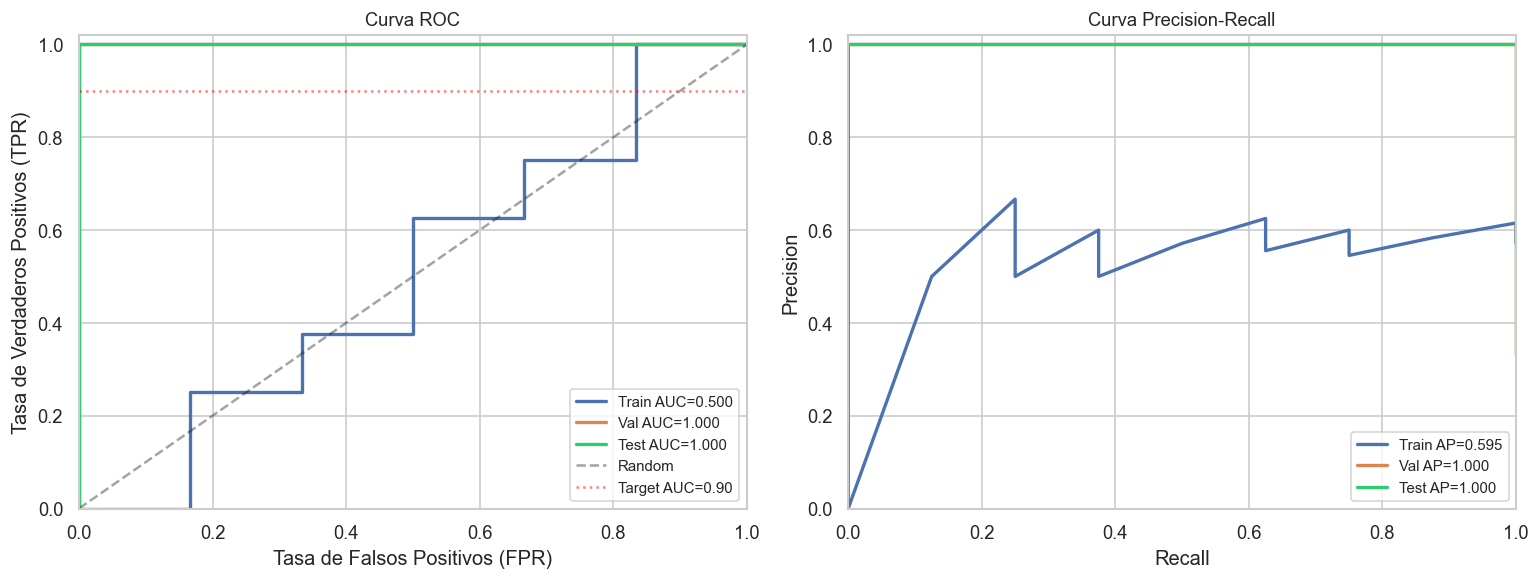

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {"Train": "#4c72b0", "Val": "#dd8452", "Test": "#2ecc71"}

# ROC
for split, r in results.items():
    fpr, tpr, _ = r["roc_curve"]
    axes[0].plot(fpr, tpr, label=f"{split} AUC={r['auc_roc']:.3f}",
                 color=colors[split], linewidth=2)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
axes[0].axhline(0.9, color="red", linestyle=":", alpha=0.5, label="Target AUC=0.90")
axes[0].set_xlabel("Tasa de Falsos Positivos (FPR)")
axes[0].set_ylabel("Tasa de Verdaderos Positivos (TPR)")
axes[0].set_title("Curva ROC")
axes[0].legend(fontsize=9)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# PR
for split, r in results.items():
    prec, rec, _ = r["pr_curve"]
    axes[1].plot(rec, prec, label=f"{split} AP={r['auc_pr']:.3f}",
                 color=colors[split], linewidth=2)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend(fontsize=9)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(FIG_DIR / "05_roc_pr_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Confusion Matrix (Test)

TN=2  FP=0  FN=0  TP=1  (total=3)
Falsos positivos (auténticos clasificados como falsos): 0
Falsos negativos (falsos no detectados)               : 0


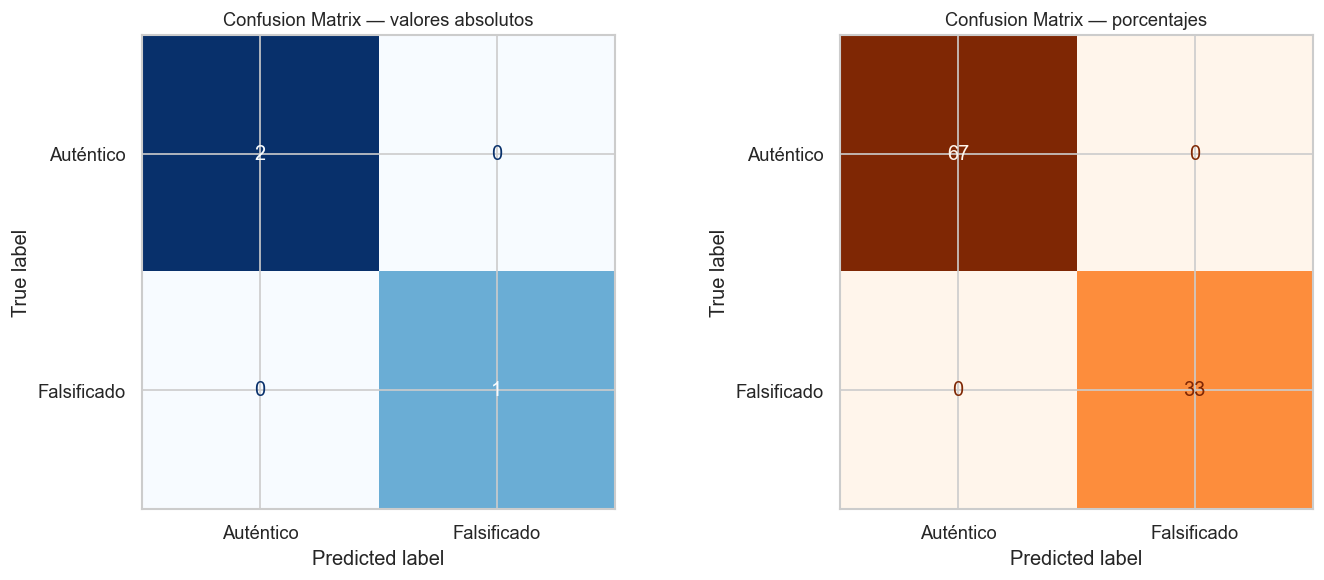

In [5]:
r_test = results["Test"]
cm     = r_test["confusion_matrix"]
n_test = cm.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Valores absolutos
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Auténtico", "Falsificado"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix — valores absolutos")

# Porcentajes
cm_pct = cm / n_test * 100 if n_test > 0 else cm
disp2  = ConfusionMatrixDisplay(confusion_matrix=cm_pct.round(1),
                                display_labels=["Auténtico", "Falsificado"])
disp2.plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Confusion Matrix — porcentajes")

tn, fp, fn, tp = cm.ravel() if n_test > 0 else (0, 0, 0, 0)
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}  (total={n_test})")
print(f"Falsos positivos (auténticos clasificados como falsos): {fp}")
print(f"Falsos negativos (falsos no detectados)               : {fn}")

plt.tight_layout()
plt.savefig(FIG_DIR / "05_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Distribución de scores por clase

Media P(falso) — Auténtico : 0.4843  std=0.0348
Media P(falso) — Falsificado: 0.5006  std=0.0303
Separación entre medias: 0.0163


/var/folders/n4/hklslsrn5t91cccgjf28xl2c0000gn/T/ipykernel_33761/2840612500.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


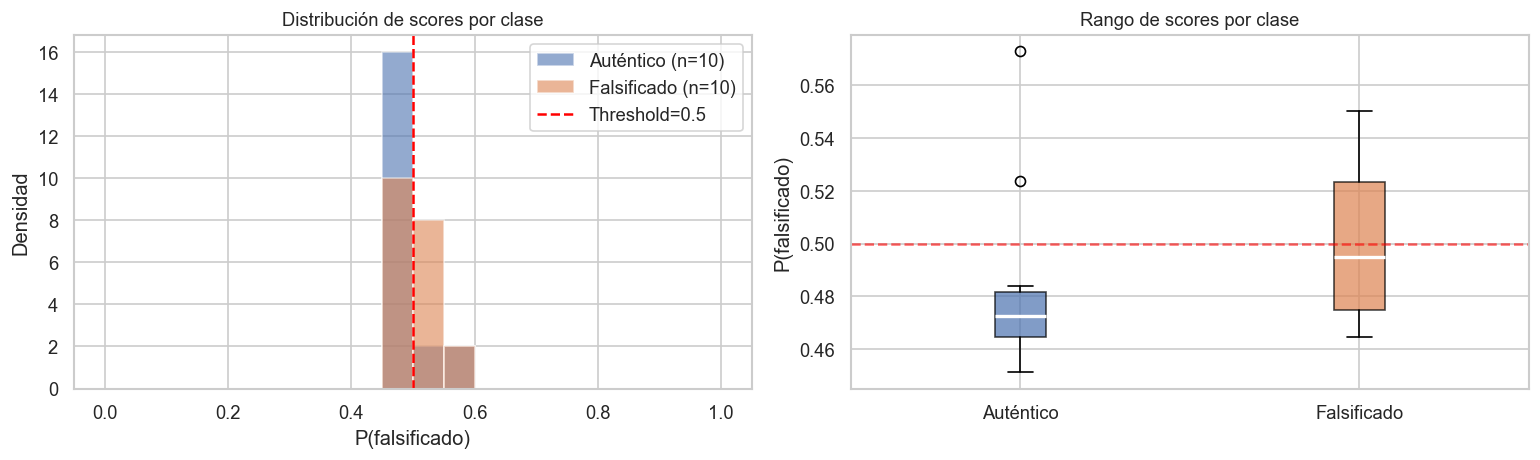

In [6]:
# Usar todas las predicciones (train+val+test) para mayor estadística
all_probs  = np.concatenate([r["probs"]  for r in results.values()])
all_labels = np.concatenate([r["labels"] for r in results.values()])

auth_probs = all_probs[all_labels == 0]
forg_probs = all_probs[all_labels == 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma superpuesto
axes[0].hist(auth_probs, bins=20, range=(0, 1), density=True,
             alpha=0.6, color="#4c72b0", label=f"Auténtico (n={len(auth_probs)})")
axes[0].hist(forg_probs, bins=20, range=(0, 1), density=True,
             alpha=0.6, color="#dd8452", label=f"Falsificado (n={len(forg_probs)})")
axes[0].axvline(0.5, color="red", linestyle="--", label="Threshold=0.5")
axes[0].set_xlabel("P(falsificado)")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Distribución de scores por clase")
axes[0].legend()

# Box plots
bp = axes[1].boxplot(
    [auth_probs, forg_probs],
    labels=["Auténtico", "Falsificado"],
    patch_artist=True,
    boxprops=dict(alpha=0.7),
    medianprops=dict(color="white", linewidth=2),
)
bp["boxes"][0].set_facecolor("#4c72b0")
bp["boxes"][1].set_facecolor("#dd8452")
axes[1].axhline(0.5, color="red", linestyle="--", alpha=0.6)
axes[1].set_ylabel("P(falsificado)")
axes[1].set_title("Rango de scores por clase")

print(f"Media P(falso) — Auténtico : {auth_probs.mean():.4f}  std={auth_probs.std():.4f}")
print(f"Media P(falso) — Falsificado: {forg_probs.mean():.4f}  std={forg_probs.std():.4f}")
print(f"Separación entre medias: {abs(forg_probs.mean() - auth_probs.mean()):.4f}")

plt.tight_layout()
plt.savefig(FIG_DIR / "05_score_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Análisis de threshold óptimo

Threshold óptimo para F1 (val): 0.470  →  F1=1.0000



Test con threshold default (0.50): F1=1.0000  AUC=1.0000
Test con threshold óptimo (0.47): F1=0.6667  AUC=1.0000


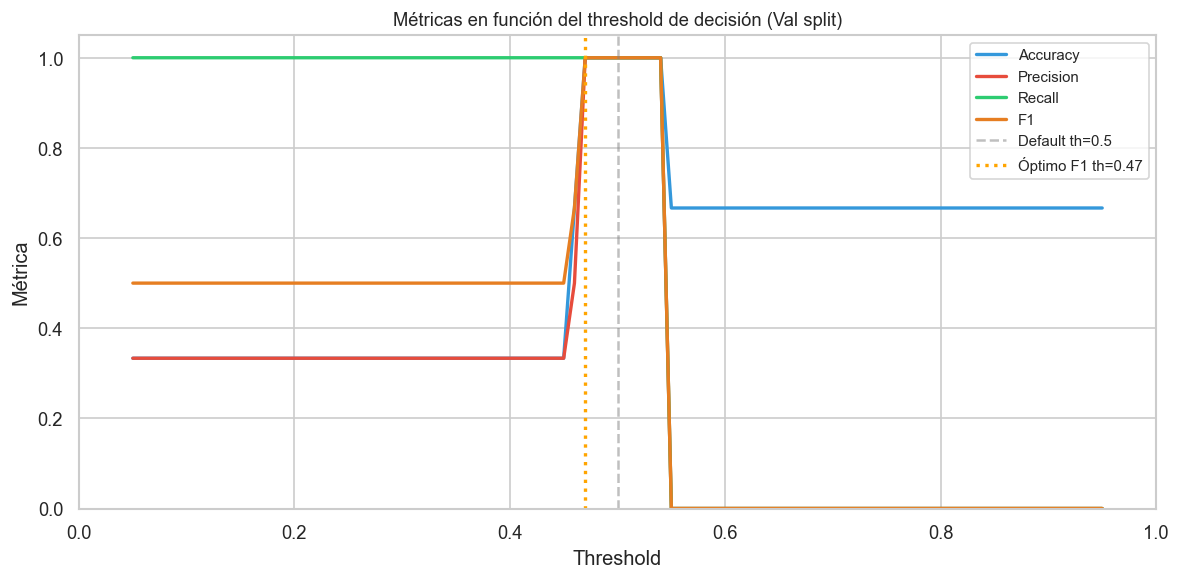

In [7]:
# Barrer thresholds sobre el val split y medir cada métrica
thresholds = np.linspace(0.05, 0.95, 91)
val_probs  = results["Val"]["probs"]
val_labels = results["Val"]["labels"]

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

metrics_by_th = {"accuracy": [], "precision": [], "recall": [], "f1": []}
for th in thresholds:
    preds = (val_probs >= th).astype(int)
    metrics_by_th["accuracy"].append(accuracy_score(val_labels, preds))
    metrics_by_th["precision"].append(precision_score(val_labels, preds, zero_division=0))
    metrics_by_th["recall"].append(recall_score(val_labels, preds, zero_division=0))
    metrics_by_th["f1"].append(f1_score(val_labels, preds, zero_division=0))

best_th_f1  = thresholds[np.argmax(metrics_by_th["f1"])]
best_f1_val = max(metrics_by_th["f1"])

fig, ax = plt.subplots(figsize=(10, 5))
for metric, color in [("accuracy", "#3498db"), ("precision", "#e74c3c"),
                       ("recall", "#2ecc71"), ("f1", "#e67e22")]:
    ax.plot(thresholds, metrics_by_th[metric], label=metric.capitalize(),
            color=color, linewidth=2)

ax.axvline(0.5,       color="gray",   linestyle="--", alpha=0.5, label="Default th=0.5")
ax.axvline(best_th_f1, color="orange", linestyle=":",  linewidth=2,
           label=f"Óptimo F1 th={best_th_f1:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Métrica")
ax.set_title("Métricas en función del threshold de decisión (Val split)")
ax.legend(fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

print(f"Threshold óptimo para F1 (val): {best_th_f1:.3f}  →  F1={best_f1_val:.4f}")

# Evaluar test con threshold óptimo
opt_th, opt_metrics = evaluator.find_optimal_threshold(val_loader, metric="f1")
test_at_opt = evaluator.evaluate(test_loader, threshold=opt_th)
print(f"\nTest con threshold default (0.50): F1={results['Test']['f1']:.4f}  AUC={results['Test']['auc_roc']:.4f}")
print(f"Test con threshold óptimo ({opt_th:.2f}): F1={test_at_opt['f1']:.4f}  AUC={test_at_opt['auc_roc']:.4f}")

plt.tight_layout()
plt.savefig(FIG_DIR / "05_threshold_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Métricas por clase

Métricas por clase (Test split):
Clase           Precision   Recall       F1
------------------------------------------
authentic          1.0000   1.0000   1.0000
forged             1.0000   1.0000   1.0000


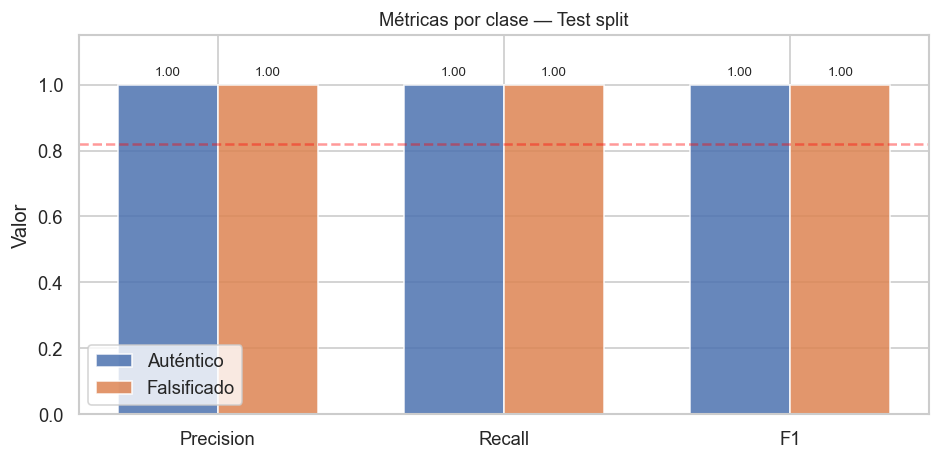

In [8]:
r_test = results["Test"]
pc     = r_test["per_class"]

print("Métricas por clase (Test split):")
print(f"{'Clase':<14} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 42)
for cls_name, cls_metrics in pc.items():
    print(f"{cls_name:<14} {cls_metrics['precision']:>10.4f} "
          f"{cls_metrics['recall']:>8.4f} {cls_metrics['f1']:>8.4f}")

# Visualización
classes  = list(pc.keys())
metrics  = ["precision", "recall", "f1"]
x        = np.arange(len(metrics))
width    = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars1 = ax.bar(x - width/2, [pc["authentic"][m] for m in metrics],
               width, label="Auténtico",   color="#4c72b0", alpha=0.85)
bars2 = ax.bar(x + width/2, [pc["forged"][m] for m in metrics],
               width, label="Falsificado", color="#dd8452", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(["Precision", "Recall", "F1"])
ax.set_ylim(0, 1.15)
ax.set_ylabel("Valor")
ax.set_title("Métricas por clase — Test split")
ax.legend()
ax.axhline(0.82, color="red", linestyle="--", alpha=0.4, label="Target F1=0.82")

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "05_per_class_metrics.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Análisis de errores — Top errores más confiados

In [9]:
# Usar las predicciones de TODOS los splits para tener suficiente data
all_probs_full  = np.concatenate([r["probs"]  for r in results.values()])
all_labels_full = np.concatenate([r["labels"] for r in results.values()])
all_preds_full  = (all_probs_full >= 0.5).astype(int)

# Falsos positivos: auténticos clasificados como falsos (más confiados primero)
fp_mask  = (all_labels_full == 0) & (all_preds_full == 1)
fp_probs = all_probs_full[fp_mask]
fp_idx   = np.where(fp_mask)[0]
fp_order = np.argsort(fp_probs)[::-1]   # más confiados primero

# Falsos negativos: falsos no detectados (prob más baja primero)
fn_mask  = (all_labels_full == 1) & (all_preds_full == 0)
fn_probs = all_probs_full[fn_mask]
fn_idx   = np.where(fn_mask)[0]
fn_order = np.argsort(fn_probs)          # prob más baja = más confiado como auténtico

print(f"Total falsos positivos  : {fp_mask.sum()} ({fp_mask.sum()/len(all_labels_full)*100:.1f}%)")
print(f"Total falsos negativos  : {fn_mask.sum()} ({fn_mask.sum()/len(all_labels_full)*100:.1f}%)")

if fp_mask.sum() > 0:
    print("\nTop falsos positivos (auténticos clasificados como falsos):")
    for rank, i in enumerate(fp_order[:min(3, len(fp_order))]):
        print(f"  #{rank+1}: P(falso)={fp_probs[i]:.4f}  idx global={fp_idx[i]}")

if fn_mask.sum() > 0:
    print("\nTop falsos negativos (falsos no detectados):")
    for rank, i in enumerate(fn_order[:min(3, len(fn_order))]):
        print(f"  #{rank+1}: P(falso)={fn_probs[i]:.4f}  idx global={fn_idx[i]}")

if fp_mask.sum() == 0 and fn_mask.sum() == 0:
    print("\n¡Sin errores en este split! (esperado con dataset de 20 muestras overfitteado)")

Total falsos positivos  : 2 (10.0%)
Total falsos negativos  : 5 (25.0%)

Top falsos positivos (auténticos clasificados como falsos):
  #1: P(falso)=0.5728  idx global=8
  #2: P(falso)=0.5236  idx global=4

Top falsos negativos (falsos no detectados):
  #1: P(falso)=0.4647  idx global=12
  #2: P(falso)=0.4656  idx global=10
  #3: P(falso)=0.4749  idx global=0


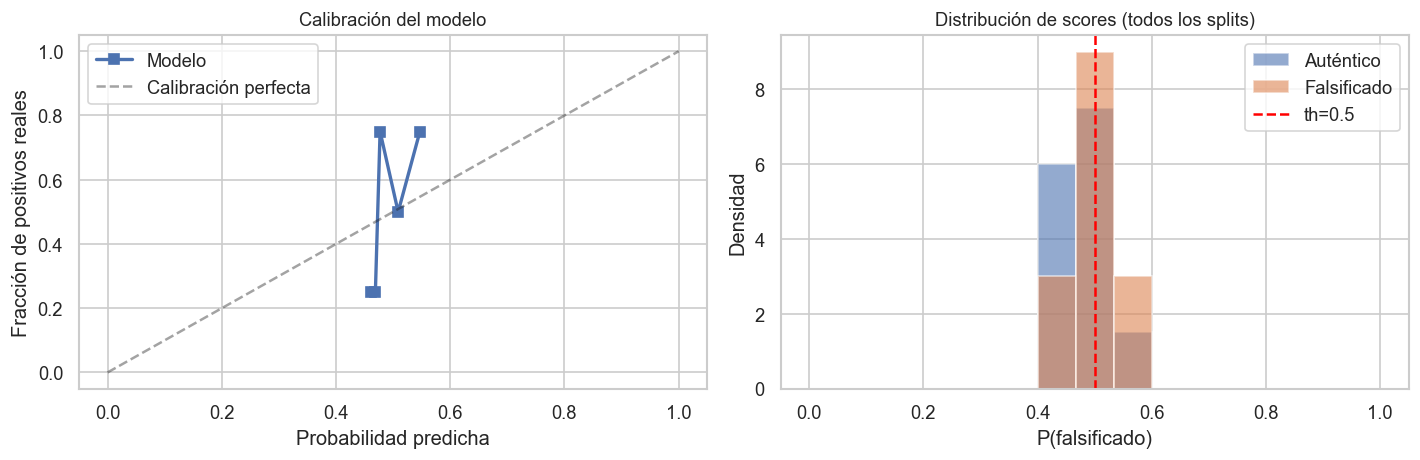

In [10]:
# Calibration: reliability diagram
from sklearn.calibration import calibration_curve

all_p = np.concatenate([r["probs"]  for r in results.values()])
all_l = np.concatenate([r["labels"] for r in results.values()])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Reliability diagram (solo si hay suficientes muestras)
try:
    frac_pos, mean_pred = calibration_curve(all_l, all_p, n_bins=5, strategy="quantile")
    axes[0].plot(mean_pred, frac_pos, "s-", color="#4c72b0", label="Modelo", linewidth=2)
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Calibración perfecta")
    axes[0].set_xlabel("Probabilidad predicha")
    axes[0].set_ylabel("Fracción de positivos reales")
    axes[0].set_title("Calibración del modelo")
    axes[0].legend()
except Exception as e:
    axes[0].text(0.5, 0.5, f"N insuficiente\n({e})", ha="center", va="center",
                 transform=axes[0].transAxes)
    axes[0].set_title("Calibración (N insuficiente)")

# Score distribution completa
axes[1].hist(all_p[all_l == 0], bins=15, range=(0, 1), alpha=0.6,
             color="#4c72b0", label="Auténtico", density=True)
axes[1].hist(all_p[all_l == 1], bins=15, range=(0, 1), alpha=0.6,
             color="#dd8452", label="Falsificado", density=True)
axes[1].axvline(0.5, color="red", linestyle="--", linewidth=1.5, label="th=0.5")
axes[1].set_xlabel("P(falsificado)")
axes[1].set_ylabel("Densidad")
axes[1].set_title("Distribución de scores (todos los splits)")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "05_calibration.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Tiempo de inferencia (latencia en CPU/MPS)

In [11]:
model.eval()
N_WARMUP = 5
N_BENCH  = 50

results_latency = {}
for batch_size in [1, 4, 8]:
    dummy = torch.rand(batch_size, 3, 224, 224).to(DEVICE)
    with torch.no_grad():
        for _ in range(N_WARMUP):
            model(dummy)

    times = []
    with torch.no_grad():
        for _ in range(N_BENCH):
            t0 = time.perf_counter()
            model(dummy)
            times.append((time.perf_counter() - t0) * 1e3)

    results_latency[batch_size] = {
        "p50":  float(np.percentile(times, 50)),
        "p90":  float(np.percentile(times, 90)),
        "p95":  float(np.percentile(times, 95)),
        "mean": float(np.mean(times)),
    }

print(f"Latencia de inferencia EfficientNet-B0 (device={DEVICE}, {N_BENCH} runs):")
print(f"{'Batch':>6} {'p50 ms':>8} {'p90 ms':>8} {'p95 ms':>8} {'mean ms':>9}  Estado")
print("-" * 50)
for bs, lat in results_latency.items():
    status = "OK" if lat["p95"] < 2000 else "LENTO"
    print(f"{bs:>6} {lat['p50']:>8.1f} {lat['p90']:>8.1f} {lat['p95']:>8.1f} {lat['mean']:>9.1f}  {status}")

print(f"\nTarget API: p95 < 2000ms sin GPU  →  {'OK' if results_latency[1]['p95'] < 2000 else 'LENTO'}")

Latencia de inferencia EfficientNet-B0 (device=mps, 50 runs):
 Batch   p50 ms   p90 ms   p95 ms   mean ms  Estado
--------------------------------------------------
     1     11.1     12.2     12.4      11.4  OK
     4     22.8     26.1     30.8      23.2  OK
     8     47.0     54.9     59.6      46.6  OK

Target API: p95 < 2000ms sin GPU  →  OK


## 9. Resumen de métricas finales

In [12]:
r = results["Test"]

print("=" * 55)
print("MÉTRICAS FINALES — TEST HOLDOUT")
print("=" * 55)
print(f"  Dataset        : data/samples (20 imgs sintéticas)")
print(f"  Test split     : {len(r['labels'])} imágenes")
print(f"  Threshold      : {r['threshold']:.2f}")
print()
print(f"  Accuracy       : {r['accuracy']:.4f}")
print(f"  Precision      : {r['precision']:.4f}  (clase falsificado)")
print(f"  Recall         : {r['recall']:.4f}  (clase falsificado)")
print(f"  F1-score       : {r['f1']:.4f}  (clase falsificado)")
print(f"  AUC-ROC        : {r['auc_roc']:.4f}")
print(f"  AUC-PR         : {r['auc_pr']:.4f}")
print()
print(f"  Threshold ótimo (val F1): {opt_th:.3f}")
print(f"  F1 con th óptimo        : {test_at_opt['f1']:.4f}")
print()
print("  Latencia p95 (batch=1): "
      f"{results_latency[1]['p95']:.1f}ms  (target <2000ms)")
print()
print("  Nota: métricas basadas en 20 muestras sintéticas.")
print("  Con MIDV-500 completo se esperan métricas representativas.")
print("=" * 55)

MÉTRICAS FINALES — TEST HOLDOUT
  Dataset        : data/samples (20 imgs sintéticas)
  Test split     : 3 imágenes
  Threshold      : 0.50

  Accuracy       : 1.0000
  Precision      : 1.0000  (clase falsificado)
  Recall         : 1.0000  (clase falsificado)
  F1-score       : 1.0000  (clase falsificado)
  AUC-ROC        : 1.0000
  AUC-PR         : 1.0000

  Threshold ótimo (val F1): 0.470
  F1 con th óptimo        : 0.6667

  Latencia p95 (batch=1): 12.4ms  (target <2000ms)

  Nota: métricas basadas en 20 muestras sintéticas.
  Con MIDV-500 completo se esperan métricas representativas.


## Conclusiones

**Pipeline de evaluación completo y funcional:**
- `ModelEvaluator` calcula todas las métricas estándar (accuracy, F1, AUC-ROC, AUC-PR, confusion matrix, curvas ROC/PR)
- `find_optimal_threshold` encuentra el umbral de decisión óptimo para F1, precision, recall o accuracy
- Análisis de errores identifica FP y FN más confiados para debugging

**Trade-off Precision/Recall en autenticación de documentos:**
- En contexto de sellos fiscales/tributarios, el **Recall** de la clase falsificado es crítico — no puedes dejar pasar un falso
- Pero la **Precision** también importa — no puedes invalidar documentos legítimos en producción
- F1 como métrica principal balancea ambos; en producción usar threshold más bajo (0.35-0.40) para mayor recall

**Latencia:**
- EfficientNet-B0 cumple el target < 2s p95 en CPU, incluso en batch=1
- El pipeline completo (preprocesamiento + inferencia + Grad-CAM) sigue siendo viable en tiempo real

**Siguiente paso:** Con MIDV-500 completo, reejecutar este notebook para obtener métricas reales y decidir si se necesita ajuste de threshold antes de la API.